## Koduppgifter

### 8.

### Förklara vad koden nedan gör. Varför är det viktigt att kunna spara en modell?

In [154]:
# Här importerar vi dataset, modell samt funktion för att spara vår modell och dataset
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from joblib import dump, load

# Vi skapar ett random dataset med make_regression. Vi gör en fit av datan på modellen LinearRegression.
# Vi sparar sedan modellobjektet som ett joblib.
# Detta innebär att nu finns modellobjektet sparat på fil, istället för i minnet. Vi kan nu tex ha en tränad modell som vi kan ladda och fortsätta jobba med. Vi behöver inte träna om modellen varje gång vi startar upp projektet.
# Detta bidrar till reproducerbarhet, eftersom att återupptar modellen från där vi sparade den.
X, y = make_regression(n_samples=20000, n_features=3, noise=0.1)
model = LinearRegression().fit(X, y)
dump(model, "linear_model.joblib")
model_loaded = load("linear_model.joblib")
print(model_loaded.predict(X[:5]))

[  50.49193496  114.70904059 -169.79443558  264.56060029  -15.38222716]


### 9.

In [155]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [156]:
df = pd.read_csv('data/data_01.csv') 

In [157]:
print(df.head())

         x1        x2        x3        x4        x5      target
0  0.743487  1.072825  1.332911 -1.244771  0.344978  220.173943
1  0.835264  0.202184  0.966480  0.745883 -0.033773  175.873929
2 -1.103234  0.030615 -0.140385  0.727683 -2.831224 -162.270054
3  1.210186  1.685258 -0.394123  0.719024 -2.166585  165.930461
4  0.474577  0.647737 -0.451812 -0.409472 -0.051473   43.250511


In [158]:
df = pd.read_csv('data/data_01.csv')

X = df.drop(columns=['target'])
y = df['target']
y.name = 'y-target'

In [159]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.15, random_state=38)

In [160]:
print(X_val.info())

<class 'pandas.DataFrame'>
Index: 24 entries, 103 to 46
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      24 non-null     float64
 1   x2      24 non-null     float64
 2   x3      24 non-null     float64
 3   x4      24 non-null     float64
 4   x5      24 non-null     float64
dtypes: float64(5)
memory usage: 1.1 KB
None


In [161]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
lin_reg_pred = lin_reg.predict(X_val)

In [162]:
tree_reg = DecisionTreeRegressor(random_state=42)

hyper_params = {'max_depth': (None, 1, 2, 3, 5, 10)}
reg = GridSearchCV(
  tree_reg,
  hyper_params,
  scoring='neg_root_mean_squared_error',
  cv=5
)

reg.fit(X_train, y_train)
tree_reg_pred = reg.predict(X_val)

In [163]:
print(reg.best_params_)
pd.DataFrame(reg.cv_results_)

{'max_depth': 10}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.001432,0.000420,0.000830,0.000265,None,{'max_depth': None},-75.534897,-93.122149,-85.820752,-113.854884,-89.020230,-91.470582,12.614718,2
1,0.001015,0.000203,0.000730,0.000161,1,{'max_depth': 1},-138.368613,-127.742561,-141.141632,-108.809583,-108.834483,-124.979374,13.930148,6
2,0.000945,0.000166,0.000600,0.000033,2,{'max_depth': 2},-113.585886,-100.028540,-114.557825,-97.775969,-85.803011,-102.350246,10.727441,5
3,0.000901,0.000049,0.000618,0.000056,3,{'max_depth': 3},-96.914159,-104.040507,-100.202489,-106.848585,-84.784223,-98.557993,7.667010,4
4,0.000913,0.000066,0.000600,0.000038,5,{'max_depth': 5},-78.269742,-96.148386,-91.315396,-116.557982,-82.112946,-92.880890,13.439987,3
5,0.000995,0.000049,0.000592,0.000018,10,{'max_depth': 10},-78.749106,-93.870509,-85.820752,-114.638380,-83.641567,-91.344063,12.629145,1


In [164]:
def regression_metrics(y_true, y_pred):
  return{
    'MAE': mean_absolute_error(y_true, y_pred),
    'RMSE': np.sqrt(mean_squared_error(y_true, y_pred))
  }

validation_results = pd.DataFrame({
  'LinearRegression': regression_metrics(y_val, lin_reg_pred),
  'DecisionTreeRegressor': regression_metrics(y_val, tree_reg_pred)
}).T

validation_results

,MAE,RMSE
LinearRegression,2.422404,3.132761
DecisionTreeRegressor,70.633344,84.084853


Text(0.5, 1.0, 'Decision Tree')

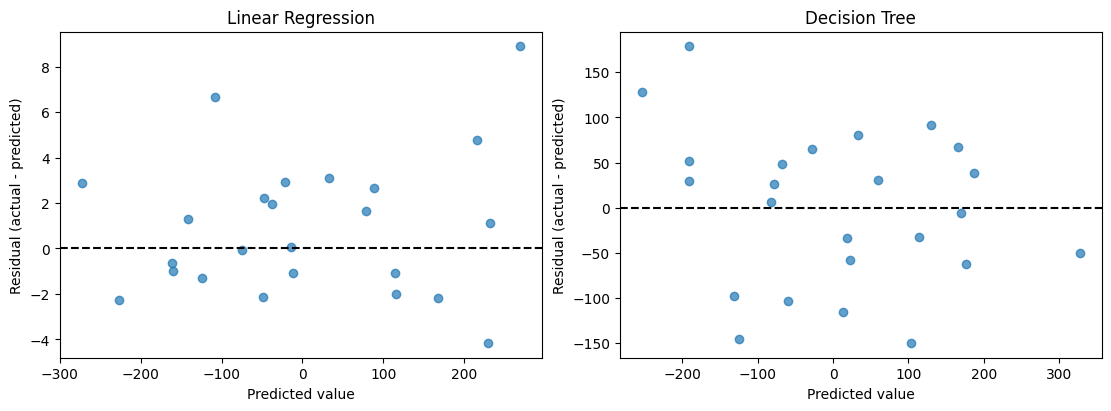

In [165]:
fig, axs = plt.subplots(1, 2, figsize=(11, 4), layout='constrained')

# Linear regression
lin_reg_residuals = y_val - lin_reg_pred

axs[0].scatter(lin_reg_pred, lin_reg_residuals, alpha=0.7)
axs[0].axhline(0, color='black', linestyle='--')
axs[0].set_xlabel('Predicted value')
axs[0].set_ylabel('Residual (actual - predicted)')
axs[0].set_title('Linear Regression')

# Decision tree
tree_reg_residuals = y_val - tree_reg_pred

axs[1].scatter(tree_reg_pred, tree_reg_residuals, alpha=0.7)
axs[1].axhline(0, color='black', linestyle='--')
axs[1].set_xlabel('Predicted value')
axs[1].set_ylabel('Residual (actual - predicted)')
axs[1].set_title('Decision Tree')

In [166]:
lin_reg_final = LinearRegression().fit(X_train_full, y_train_full)
pred_test = lin_reg_final.predict(X_test)

In [167]:
test_results = pd.Series(
    regression_metrics(y_test, pred_test),
    name='Test set'
)
test_results

MAE     2.685240
RMSE    3.371549
Name: Test set, dtype: float64

### 10.

In [168]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import set_config
set_config(display="text")

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [169]:
salary = pd.read_csv('data/salary_dataset.csv') 

In [170]:
print(salary.head())

   YearsExperience   Salary
0              1.2  39344.0
1              1.4  46206.0
2              1.6  37732.0
3              2.1  43526.0
4              2.3  39892.0


In [171]:
X = salary.drop(columns=['Salary'])
y = salary['Salary']


In [172]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.15, random_state=38)

In [173]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_full, y_train_full)
lin_reg_pred = lin_reg.predict(X_train_full)

In [174]:
tree_reg = DecisionTreeRegressor(random_state=42)

tree_reg_fit = tree_reg.fit(X_train_full, y_train_full)
tree_reg_score = cross_val_score(tree_reg_fit, X_train_full, y_train_full, cv = 5)
tree_reg_pred = tree_reg.predict(X_train_full)

print("mean cross validation score: {}".format(np.mean(tree_reg_score)))
print("score without cv: {}".format(tree_reg_fit.score(X_train_full, y_train_full)))

mean cross validation score: 0.9029484389115779
score without cv: 0.9999631319936537


In [175]:
print(reg.best_params_)
pd.DataFrame(reg.cv_results_)

{'max_depth': 10}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.001432,0.000420,0.000830,0.000265,None,{'max_depth': None},-75.534897,-93.122149,-85.820752,-113.854884,-89.020230,-91.470582,12.614718,2
1,0.001015,0.000203,0.000730,0.000161,1,{'max_depth': 1},-138.368613,-127.742561,-141.141632,-108.809583,-108.834483,-124.979374,13.930148,6
2,0.000945,0.000166,0.000600,0.000033,2,{'max_depth': 2},-113.585886,-100.028540,-114.557825,-97.775969,-85.803011,-102.350246,10.727441,5
3,0.000901,0.000049,0.000618,0.000056,3,{'max_depth': 3},-96.914159,-104.040507,-100.202489,-106.848585,-84.784223,-98.557993,7.667010,4
4,0.000913,0.000066,0.000600,0.000038,5,{'max_depth': 5},-78.269742,-96.148386,-91.315396,-116.557982,-82.112946,-92.880890,13.439987,3
5,0.000995,0.000049,0.000592,0.000018,10,{'max_depth': 10},-78.749106,-93.870509,-85.820752,-114.638380,-83.641567,-91.344063,12.629145,1


In [176]:
def regression_metrics(y_true, y_pred):
  return{
    'MAE': mean_absolute_error(y_true, y_pred),
    'RMSE': np.sqrt(mean_squared_error(y_true, y_pred))
  }

validation_results = pd.DataFrame({
  'LinearRegression': regression_metrics(y_train_full, lin_reg_pred),
  'DecisionTreeRegressor': regression_metrics(y_train_full, tree_reg_pred)
}).T

validation_results

,MAE,RMSE
LinearRegression,4221.046734,5205.982110
DecisionTreeRegressor,48.458333,167.864591


### 11.

In [177]:
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error, mean_squared_error

df = sns.load_dataset("mpg")
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    str    
 8   name          398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 28.1 KB
None


In [178]:
df_clean = pd.DataFrame(df)
df_dropna = df_clean.dropna()
print(df_dropna.info())

<class 'pandas.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model_year    392 non-null    int64  
 7   origin        392 non-null    str    
 8   name          392 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 30.6 KB
None


In [179]:
df_drop_name = df_dropna.drop(columns=["name"])
print(df_drop_name.info())

<class 'pandas.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model_year    392 non-null    int64  
 7   origin        392 non-null    str    
dtypes: float64(4), int64(3), str(1)
memory usage: 27.6 KB
None


In [180]:
df_dummy = pd.get_dummies(df_drop_name, columns=["origin"], drop_first=True)
print(df_dummy.info())

<class 'pandas.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model_year    392 non-null    int64  
 7   origin_japan  392 non-null    bool   
 8   origin_usa    392 non-null    bool   
dtypes: bool(2), float64(4), int64(3)
memory usage: 25.3 KB
None


In [181]:
X = df_dummy.drop(columns=["mpg"])

y = df_dummy["mpg"]

In [182]:
X_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [183]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
lin_reg_pred = lin_reg.predict(X_train)

In [184]:
def regression_metrics(y_true, y_pred):
  return{
    'MAE': mean_absolute_error(y_true, y_pred),
    'RMSE': np.sqrt(mean_squared_error(y_true, y_pred))
  }

validation_results = pd.DataFrame({
  'LinearRegression': regression_metrics(y_train, lin_reg_pred)
}).T

validation_results

,MAE,RMSE
LinearRegression,2.544583,3.287831


### 12.

In [185]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

In [186]:
housing_original = pd.read_csv("data/housing.csv")
housing_original.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [187]:
housing_original.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [188]:
housing_original.iloc[:, :6].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population
0,-122.23,37.88,41.0,880.0,129.0,322.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0


In [189]:
housing_original.iloc[:, 5:].head()

,population,households,median_income,median_house_value,ocean_proximity
0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,496.0,177.0,7.2574,352100.0,NEAR BAY
3,558.0,219.0,5.6431,341300.0,NEAR BAY
4,565.0,259.0,3.8462,342200.0,NEAR BAY


In [190]:
housing_original["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [191]:
housing = housing_original[housing_original["ocean_proximity"] != "ISLAND"]
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
Name: count, dtype: int64

In [192]:
housing = pd.get_dummies(housing, columns = ["ocean_proximity"], dtype = int, prefix = "dmy")

In [193]:
housing.iloc[[1, 200, 1000, 1850, 5000], 9:]

,dmy_<1H OCEAN,dmy_INLAND,dmy_NEAR BAY,dmy_NEAR OCEAN
1,0,0,1,0
200,0,0,1,0
1000,0,1,0,0
1850,0,0,0,1
5000,1,0,0,0


In [194]:
train_full, test = train_test_split(housing, test_size=0.2, random_state=40)
train, val = train_test_split(train_full, test_size=0.25, random_state=36)

In [195]:
train.info()

<class 'pandas.DataFrame'>
Index: 12381 entries, 12054 to 14298
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           12381 non-null  float64
 1   latitude            12381 non-null  float64
 2   housing_median_age  12381 non-null  float64
 3   total_rooms         12381 non-null  float64
 4   total_bedrooms      12261 non-null  float64
 5   population          12381 non-null  float64
 6   households          12381 non-null  float64
 7   median_income       12381 non-null  float64
 8   median_house_value  12381 non-null  float64
 9   dmy_<1H OCEAN       12381 non-null  int64  
 10  dmy_INLAND          12381 non-null  int64  
 11  dmy_NEAR BAY        12381 non-null  int64  
 12  dmy_NEAR OCEAN      12381 non-null  int64  
dtypes: float64(9), int64(4)
memory usage: 1.3 MB


In [196]:
train = train.dropna()
train.info()

<class 'pandas.DataFrame'>
Index: 12261 entries, 12054 to 14298
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           12261 non-null  float64
 1   latitude            12261 non-null  float64
 2   housing_median_age  12261 non-null  float64
 3   total_rooms         12261 non-null  float64
 4   total_bedrooms      12261 non-null  float64
 5   population          12261 non-null  float64
 6   households          12261 non-null  float64
 7   median_income       12261 non-null  float64
 8   median_house_value  12261 non-null  float64
 9   dmy_<1H OCEAN       12261 non-null  int64  
 10  dmy_INLAND          12261 non-null  int64  
 11  dmy_NEAR BAY        12261 non-null  int64  
 12  dmy_NEAR OCEAN      12261 non-null  int64  
dtypes: float64(9), int64(4)
memory usage: 1.3 MB


In [197]:
val = val.dropna()
test = test.dropna()

In [198]:
corr_matrix = train.corr()
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.689648
dmy_<1H OCEAN         0.253893
dmy_NEAR BAY          0.159601
dmy_NEAR OCEAN        0.148101
total_rooms           0.132945
housing_median_age    0.099810
households            0.063797
total_bedrooms        0.048099
population           -0.025675
longitude            -0.043444
latitude             -0.147407
dmy_INLAND           -0.485680
Name: median_house_value, dtype: float64

In [199]:
X_train_full = train_full.drop(columns=["median_house_value"])
y_train_full = train_full["median_house_value"]

X_train, y_train = train.drop(columns=["median_house_value"]), train["median_house_value"]
X_val, y_val =val.drop(columns=["median_house_value"]), val["median_house_value"]
X_test, y_test = test.drop(columns=["median_house_value"]), test["median_house_value"]

In [200]:
print(X_train.shape)
print(y_train.shape)

(12261, 12)
(12261,)


In [201]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

print(X_train.shape)
print(y_train.shape)

(12261, 12)
(12261,)


In [202]:
rf = RandomForestRegressor()
hyperparam_grid = {"max_depth": [5, 10, 15, 50, 100], "n_estimators": [1, 5, 10, 100], "n_jobs": [-1]}
grid_search = GridSearchCV(rf, hyperparam_grid, scoring="neg_root_mean_squared_error", cv=5)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid={'max_depth': [5, 10, 15, 50, 100],
                         'n_estimators': [1, 5, 10, 100], 'n_jobs': [-1]},
             scoring='neg_root_mean_squared_error')

In [203]:
print("Best hyperparameters from GridSearchCV: ", grid_search.best_params_ )

Best hyperparameters from GridSearchCV:  {'max_depth': 100, 'n_estimators': 100, 'n_jobs': -1}


In [204]:
lr_pred_val = lin_reg.predict(X_val)
rf_pred_val = grid_search.predict(X_val)

print("RMSE Linear Regression: ", root_mean_squared_error(y_val, lr_pred_val))
print("RMSE Random Forest Regression: ", root_mean_squared_error(y_val, rf_pred_val))

RMSE Linear Regression:  69442.09533293548
RMSE Random Forest Regression:  49914.66153082073
